Usando o Dataset AirPassengers direto do statsmodels


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# carrega AirPassengers direto do statsmodels
from statsmodels.datasets import get_rdataset
df_air = get_rdataset('AirPassengers').data

# inspeciona
print(df_air.head())
print(df_air.dtypes)
print(df_air.shape)

          time  value
0  1949.000000    112
1  1949.083333    118
2  1949.166667    132
3  1949.250000    129
4  1949.333333    121
time     float64
value      int64
dtype: object
(144, 2)


Converter a coluna "time", pois a mesma esta como float, preciso converter para usar como índice temporal

In [19]:
# converter o índice para datetime mensal

df_air['date'] = pd.date_range(start='1949-01-01', periods=len(df_air), freq='MS')
df_air = df_air.set_index('date')[['value']]
df_air.columns = ['AirPassengers']

print(df_air.head())
print(df_air.tail())

            AirPassengers
date                     
1949-01-01            112
1949-02-01            118
1949-03-01            132
1949-04-01            129
1949-05-01            121
            AirPassengers
date                     
1960-08-01            606
1960-09-01            508
1960-10-01            461
1960-11-01            390
1960-12-01            432


Primeira visualização dos dados, para avaliação do dataset

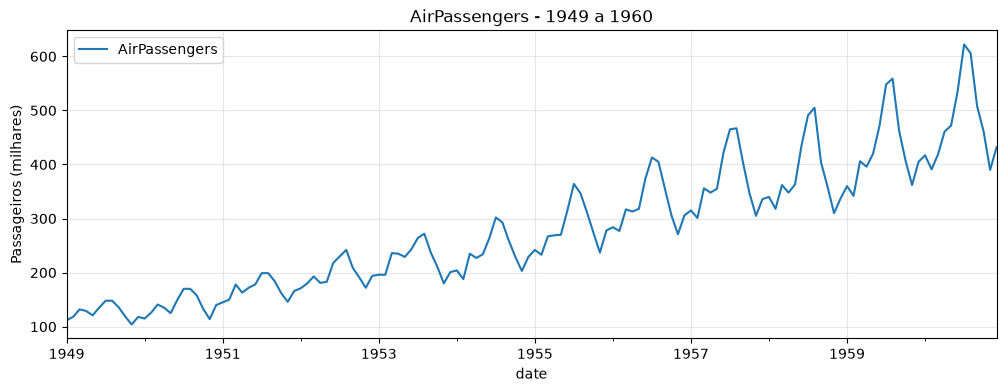

In [20]:
df_air.plot(figsize=(12, 4), title='AirPassengers - 1949 a 1960')
plt.ylabel('Passageiros (milhares)')
plt.grid(alpha=0.3)
plt.show()

Estudando as métricas, importando do SKlearn

In [21]:
def mse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def mape(y_true, y_pred):
    # sklearn retorna proporção (0.1 = 10%), multiplico por 100 para percentual
    return mean_absolute_percentage_error(y_true, y_pred) * 100

Métricas gerais - implementação manual

In [22]:
def pocid(y_true, y_pred):
    # POCID: mede se o modelo acerta a direção do movimento
    # compara a variação real com a variação prevista
    y_true = np.asanyarray(y_true)
    y_pred = np.asanyarray(y_pred)

    # diferenças entre pontos consecutivos
    dif_real = np.diff(y_true)
    dif_pred = np.diff(y_pred)

    # produto > 0 significa que ambos foram na mesma direção
    acertos = (dif_real * dif_pred) > 0

    return 100 * np.mean(acertos)


def arv(y_true, y_pred):
    # ARV: compara erro do modelo com erro de prever a média
    # ARV < 1 -> modelo melhor que a média
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    numerador = np.sum((y_true - y_pred) ** 2)
    denominador = np.sum((y_true - np.mean(y_true)) ** 2)

    return numerador / denominador


def u_theil(y_true, y_pred):
    # U de Theil: compara modelo com naive (y_t = y_{t-1})
    # U < 1 -> modelo melhor que naive
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # erro do modelo entre t=1 e t=n
    numerador = np.sum((y_true[1:] - y_pred[1:]) ** 2)
    # erro do naive: prever y_{t-1} como sendo y_t
    denominador = np.sum((y_true[1:] - y_true[:-1]) ** 2)

    return np.sqrt(numerador / denominador)


# ---------------------- Função Consolidada -------------------------------------

def gerar_metricas(y_true, y_pred):
    return {
        'MSE': mse(y_true, y_pred),
        'RMSE': rmse(y_true, y_pred),
        'MAE': mae(y_true, y_pred),
        'MAPE': mape(y_true, y_pred),
        'POCID': pocid(y_true, y_pred),
        'ARV': arv(y_true, y_pred),
        'U-Theil': u_theil(y_true, y_pred)
    }

In [23]:
# Teste com dados sintéticos


# cenário 1: previsão perfeita
y_true = np.array([100, 110, 105, 120, 115, 130])
y_pred_perfeito = y_true.copy()

# cenário 2: previsão = média histórica (deve dar ARV = 1)
y_pred_media = np.full_like(y_true, y_true.mean(), dtype=float)

# cenário 3: previsão naive (y_t = y_{t-1}) - deve dar U próximo de 1
y_pred_naive = np.concatenate([[y_true[0]], y_true[:-1]])

# aplica métricas
resultados = pd.DataFrame([
    {'cenario': 'perfeito', **gerar_metricas(y_true, y_pred_perfeito)},
    {'cenario': 'media',    **gerar_metricas(y_true, y_pred_media)},
    {'cenario': 'naive',    **gerar_metricas(y_true, y_pred_naive)},
])

print(resultados)

    cenario         MSE       RMSE       MAE      MAPE  POCID       ARV  \
0  perfeito    0.000000   0.000000  0.000000  0.000000  100.0  0.000000   
1     media   97.222222   9.860133  8.333333  7.354248    0.0  1.000000   
2     naive  100.000000  10.000000  8.333333  7.039850    0.0  1.028571   

    U-Theil  
0  0.000000  
1  0.822147  
2  1.000000  


Preparando o dataset para uso de janelas

In [24]:
def create_windowing(serie, lag_size):
    """
    Transforma uma série temporal em formato supervisionado com lags.
    
    Parâmetros:
        serie: pd.Series ou pd.DataFrame com uma coluna
        lag_size: quantidade de lags a criar
    
    Retorna:
        DataFrame com colunas [lag_N, ..., lag_2, lag_1, actual]
    """
    # garante que é DataFrame para o shift funcionar consistentemente
    if isinstance(serie, pd.Series):
        df = serie.to_frame()
    else:
        df = serie.copy()

    final_df = None

    # cria uma coluna para cada lag + a coluna atual (y)
    for i in range(0, lag_size + 1):
        serie_shifted = df.shift(i)

        if i == 0:
            serie_shifted.columns = ['actual']  # valor atual = target
        else:
            serie_shifted.columns = [f'lag_{i}']

        # concatena da esquerda para direita: [lag_N, ..., lag_1, actual]
        final_df = pd.concat([serie_shifted, final_df], axis=1)

    # remove linhas com NaN (as primeiras, que não têm lags completos)
    return final_df.dropna()

Aplicando no dataset AirPassagenrs

In [25]:
ts = df_air['AirPassengers']

df_lagged = create_windowing(ts, lag_size=12)

print(df_lagged.shape)
print(df_lagged.head())
print(df_lagged.tail())

(132, 13)
            lag_12  lag_11  lag_10  lag_9  lag_8  lag_7  lag_6  lag_5  lag_4  \
date                                                                           
1950-01-01   112.0   118.0   132.0  129.0  121.0  135.0  148.0  148.0  136.0   
1950-02-01   118.0   132.0   129.0  121.0  135.0  148.0  148.0  136.0  119.0   
1950-03-01   132.0   129.0   121.0  135.0  148.0  148.0  136.0  119.0  104.0   
1950-04-01   129.0   121.0   135.0  148.0  148.0  136.0  119.0  104.0  118.0   
1950-05-01   121.0   135.0   148.0  148.0  136.0  119.0  104.0  118.0  115.0   

            lag_3  lag_2  lag_1  actual  
date                                     
1950-01-01  119.0  104.0  118.0     115  
1950-02-01  104.0  118.0  115.0     126  
1950-03-01  118.0  115.0  126.0     141  
1950-04-01  115.0  126.0  141.0     135  
1950-05-01  126.0  141.0  135.0     125  
            lag_12  lag_11  lag_10  lag_9  lag_8  lag_7  lag_6  lag_5  lag_4  \
date                                                   

Separar o dataset em treino e teste, além de normalizar

In [26]:
from sklearn.preprocessing import MinMaxScaler

# quantidade de pontos reservados para teste
test_size = 28

# separa features (X) e target (y)
X = df_lagged.drop(columns=['actual'])
y = df_lagged['actual'].values.reshape(-1, 1)

# split temporal (SEM shuffle - ordem importa!)
X_train = X.iloc[:-test_size]
y_train = y[:-test_size]

X_test = X.iloc[-test_size:]
y_test = y[-test_size:]

print(f'Treino: X={X_train.shape}, y={y_train.shape}')
print(f'Teste:  X={X_test.shape},  y={y_test.shape}')

# normalização — 1 scaler para X, outro para y
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

# FIT APENAS NO TREINO
scaler_x.fit(X_train)
scaler_y.fit(y_train)

# transform em ambos
X_train_norm = scaler_x.transform(X_train)
y_train_norm = scaler_y.transform(y_train).flatten()

X_test_norm = scaler_x.transform(X_test)
y_test_norm = scaler_y.transform(y_test).flatten()

print(f'\nRange X_train_norm: [{X_train_norm.min():.3f}, {X_train_norm.max():.3f}]')
print(f'Range X_test_norm:  [{X_test_norm.min():.3f}, {X_test_norm.max():.3f}]')

Treino: X=(104, 12), y=(104, 1)
Teste:  X=(28, 12),  y=(28, 1)

Range X_train_norm: [0.000, 1.000]
Range X_test_norm:  [0.520, 1.427]


In [27]:
print("Última linha do treino:")
print(f"  Data: {X_train.index[-1]}")
print(f"  Target (y_train[-1]): {y_train[-1][0]}")

print("\nPrimeira linha do teste:")
print(f"  Data: {X_test.index[0]}")
print(f"  Target (y_test[0]): {y_test[0][0]}")

Última linha do treino:
  Data: 1958-08-01 00:00:00
  Target (y_train[-1]): 505

Primeira linha do teste:
  Data: 1958-09-01 00:00:00
  Target (y_test[0]): 404


Aplicando a diferenciação, para tratar tendências

In [28]:
def difference(dataset, interval=1):
    """
    Aplica diferenciação: y_diff[i] = y[i] - y[i-interval]
    
    Parâmetros:
        dataset: array-like com a série original
        interval: quantos passos atrás para subtrair (1 = diff simples)
    
    Retorna:
        np.array com len(dataset) - interval elementos
    """
    diff = []
    for i in range(interval, len(dataset)):
        valor = dataset[i] - dataset[i - interval]
        diff.append(valor)
    return np.array(diff)


def inverse_difference(last_ob, value):
    """Reverte 1 ponto diferenciado somando o valor original correspondente."""
    return value + last_ob


def get_inverse_difference(last_obs, values):
    """
    Reverte um array de valores diferenciados.
    
    Parâmetros:
        last_obs: valores originais da série que serviram de "base" para o diff
        values: valores diferenciados a serem revertidos
    """
    return np.array([inverse_difference(last_obs[i], values[i]) for i in range(len(values))])

Aplicando a diferenciação no dataset

In [29]:
ts = df_air['AirPassengers']

# diferenciação com intervalo 1 (para modelos 1-step)
diff_ts_1step = pd.Series(difference(ts.values, interval=1))

# diferenciação com intervalo 10 (para modelo direto de horizonte 10)
diff_ts_10step = pd.Series(difference(ts.values, interval=10))

# comparação de tamanhos
print(f'Série original:      {len(ts)} pontos')
print(f'Diff intervalo 1:    {len(diff_ts_1step)} pontos (perdeu 1)')
print(f'Diff intervalo 10:   {len(diff_ts_10step)} pontos (perdeu 10)')

# estatísticas
print(f'\nSérie original: média={ts.mean():.1f}, std={ts.std():.1f}')
print(f'Diff 1:         média={diff_ts_1step.mean():.2f}, std={diff_ts_1step.std():.2f}')
print(f'Diff 10:        média={diff_ts_10step.mean():.2f}, std={diff_ts_10step.std():.2f}')

Série original:      144 pontos
Diff intervalo 1:    143 pontos (perdeu 1)
Diff intervalo 10:   134 pontos (perdeu 10)

Série original: média=280.3, std=120.0
Diff 1:         média=2.24, std=33.75
Diff 10:        média=26.93, std=55.03


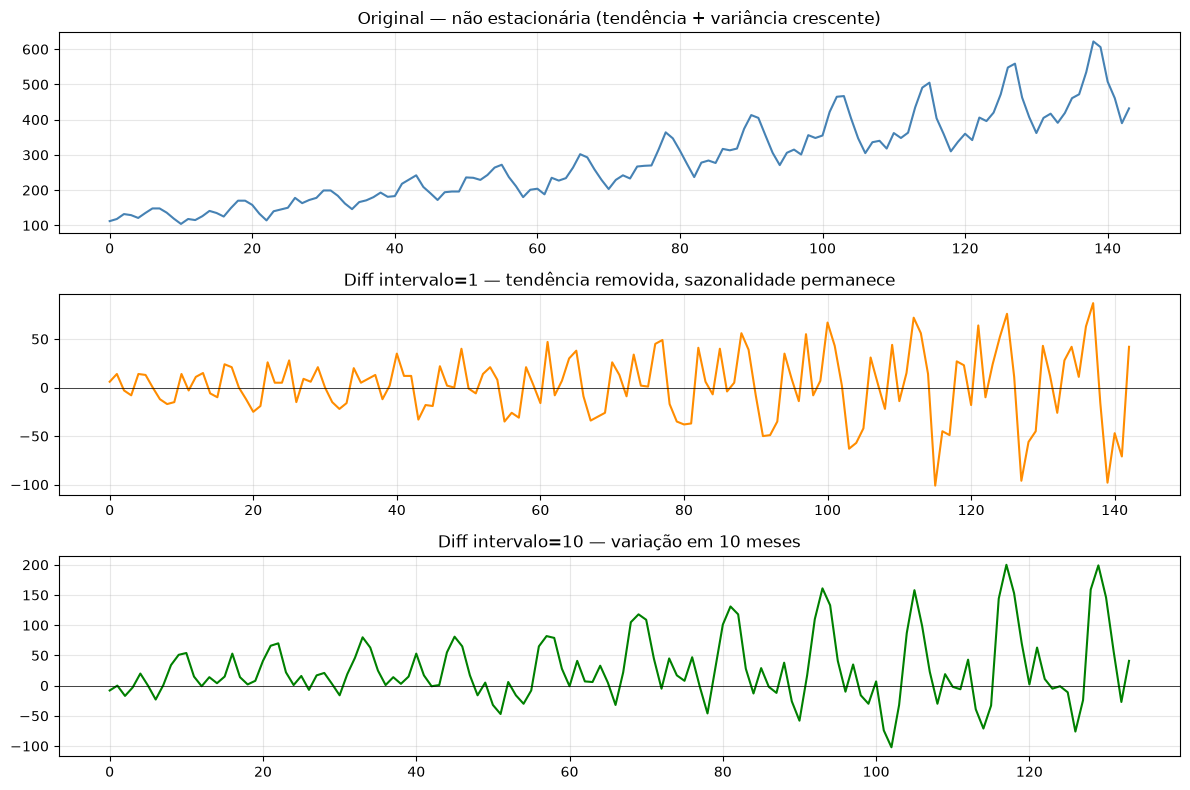

In [30]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(ts.values, color='steelblue')
axes[0].set_title('Original — não estacionária (tendência + variância crescente)')
axes[0].grid(alpha=0.3)

axes[1].plot(diff_ts_1step.values, color='darkorange')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Diff intervalo=1 — tendência removida, sazonalidade permanece')
axes[1].grid(alpha=0.3)

axes[2].plot(diff_ts_10step.values, color='green')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_title('Diff intervalo=10 — variação em 10 meses')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Preparaçaõ dos dados para ARIMA

In [31]:
# usa a mesma proporção de teste que definimos antes
test_size = 28

# separa a série original em treino e teste
ts = df_air['AirPassengers']
train = ts[:-test_size]
test = ts[-test_size:]

print(f'Treino: {len(train)} pontos ({train.index[0].date()} → {train.index[-1].date()})')
print(f'Teste:  {len(test)} pontos ({test.index[0].date()} → {test.index[-1].date()})')

Treino: 116 pontos (1949-01-01 → 1958-08-01)
Teste:  28 pontos (1958-09-01 → 1960-12-01)


In [32]:
import pmdarima as pm

# auto_arima seleciona a melhor ordem automaticamente
modelo_auto = pm.auto_arima(
    train,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    d=None,              # deixa detectar o d automaticamente
    seasonal=False,      # sem componente sazonal (SARIMA seria True)
    trace=True,          # mostra o processo de busca
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True        # busca stepwise (mais rápida que grid search)
)

print(f'\nMelhor ordem encontrada: {modelo_auto.order}')
print(modelo_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1085.082, Time=0.12 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1077.789, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1072.908, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1084.963, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1067.040, Time=0.08 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.23 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.15 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1069.380, Time=0.07 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1074.580, Time=0.07 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.23 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1066.473, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1071.935, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1076.876, Time=0.03 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=1067.470, Time=0.07 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=1066.3

In [34]:
print(f'Ordem escolhida (p, d, q): {modelo_auto.order}')
print(f'AIC: {modelo_auto.aic():.2f}')

Ordem escolhida (p, d, q): (4, 1, 2)
AIC: 1061.01


Treinando as variantes do ARIMA

In [35]:
# ARima - direct

from statsmodels.tsa.arima.model import ARIMA

# usa a ordem encontrada pelo auto_arima
ordem = modelo_auto.order

# treina uma vez no conjunto de treino
modelo_direct = ARIMA(train, order=ordem).fit()

# prevê os 28 pontos de uma vez, sem receber dados reais no meio
arima_direct = modelo_direct.forecast(steps=test_size)

print(f'Previsões direct: {len(arima_direct)} pontos')
print(arima_direct.head())

d:\UPE\02 - ST - Series Temporais\experimentos\pandaseerros\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\UPE\02 - ST - Series Temporais\experimentos\pandaseerros\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\UPE\02 - ST - Series Temporais\experimentos\pandaseerros\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Previsões direct: 28 pontos
1958-09-01    478.690313
1958-10-01    445.286209
1958-11-01    413.867738
1958-12-01    396.241644
1959-01-01    391.689746
Freq: MS, Name: predicted_mean, dtype: float64


In [36]:
# Arima - 1step

# vai armazenar cada previsão de 1 passo
arima_1step = []

# começa com todo o histórico de treino
historico = list(train.values)

# loop: prevê 1 passo, recebe o real, adiciona ao histórico, repete
for i in range(test_size):
    # treina no histórico atual
    modelo = ARIMA(historico, order=ordem).fit()
    
    # prevê 1 passo à frente
    previsao = modelo.forecast(steps=1)[0]
    arima_1step.append(previsao)
    
    # adiciona o valor REAL do teste ao histórico (rolling)
    historico.append(test.values[i])

# converte pra array com índice do teste
arima_1step = pd.Series(arima_1step, index=test.index)

print(f'Previsões 1-step: {len(arima_1step)} pontos')
print(arima_1step.head())

d:\UPE\02 - ST - Series Temporais\experimentos\pandaseerros\.venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
d:\UPE\02 - ST - Series Temporais\experimentos\pandaseerros\.venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
d:\UPE\02 - ST - Series Temporais\experimentos\pandaseerros\.venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
d:\UPE\02 - ST - Series Temporais\experimentos\pandaseerros\.venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as star

Previsões 1-step: 28 pontos
date
1958-09-01    478.690313
1958-10-01    340.822361
1958-11-01    354.108521
1958-12-01    286.761759
1959-01-01    388.540027
dtype: float64


d:\UPE\02 - ST - Series Temporais\experimentos\pandaseerros\.venv\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


In [37]:
print(test.head())

date
1958-09-01    404
1958-10-01    359
1958-11-01    310
1958-12-01    337
1959-01-01    360
Name: AirPassengers, dtype: int64


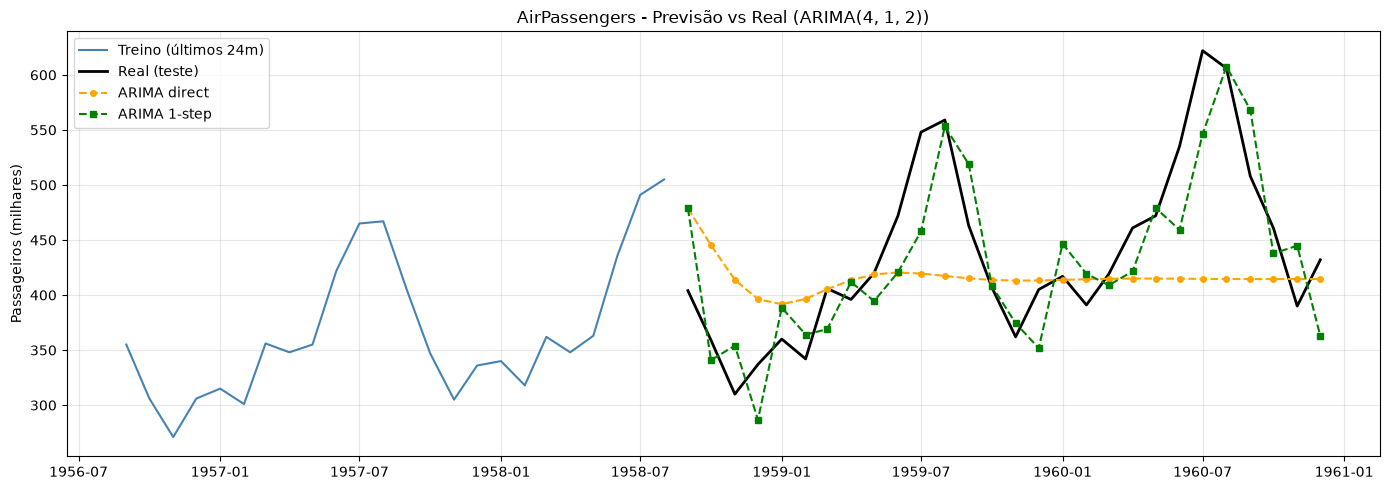

         modelo       MSE    RMSE     MAE    MAPE   POCID    ARV  U-Theil
0  arima_direct  6700.951  81.859  60.708  13.109  59.259  1.086    1.618
1   arima_1step  2060.447  45.392  37.918   8.715  62.963  0.334    0.866


In [38]:
# --- Visualização ---
plt.figure(figsize=(14, 5))

# treino (últimos 24 meses pra dar contexto)
plt.plot(train.index[-24:], train.values[-24:], label='Treino (últimos 24m)', color='steelblue')

# real de teste
plt.plot(test.index, test.values, label='Real (teste)', color='black', linewidth=2)

# previsões
plt.plot(test.index, arima_direct.values, label='ARIMA direct', 
         color='orange', linestyle='--', marker='o', markersize=4)
plt.plot(test.index, arima_1step.values, label='ARIMA 1-step',
         color='green', linestyle='--', marker='s', markersize=4)

plt.title(f'AirPassengers - Previsão vs Real (ARIMA{modelo_auto.order})')
plt.ylabel('Passageiros (milhares)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# --- Métricas ---
resultado_arima = pd.DataFrame([
    {'modelo': 'arima_direct', **gerar_metricas(test.values, arima_direct.values)},
    {'modelo': 'arima_1step',  **gerar_metricas(test.values, arima_1step.values)},
])

print(resultado_arima.round(3))